# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [ ]:
#The objective of this analysis is to identify the factors that drives the price of a car and use these factores to 
#predict future price of a car. The factors does include the cars model, features, year, location and price. Our exersize 
#objective is to identify the main factors and build a model to predict a future price of car with similar characteristics.
    

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import make_column_transformer, TransformedTargetRegressor
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SequentialFeatureSelector
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from warnings import filterwarnings 
filterwarnings('ignore')
from sklearn.metrics import mean_squared_error

                 id         price           year      odometer
count  4.268800e+05  4.268800e+05  425675.000000  4.224800e+05
mean   7.311487e+09  7.519903e+04    2011.235191  9.804333e+04
std    4.473170e+06  1.218228e+07       9.452120  2.138815e+05
min    7.207408e+09  0.000000e+00    1900.000000  0.000000e+00
25%    7.308143e+09  5.900000e+03    2008.000000  3.770400e+04
50%    7.312621e+09  1.395000e+04    2013.000000  8.554800e+04
75%    7.315254e+09  2.648575e+04    2017.000000  1.335425e+05
max    7.317101e+09  3.736929e+09    2022.000000  1.000000e+07
<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603

<Axes: >

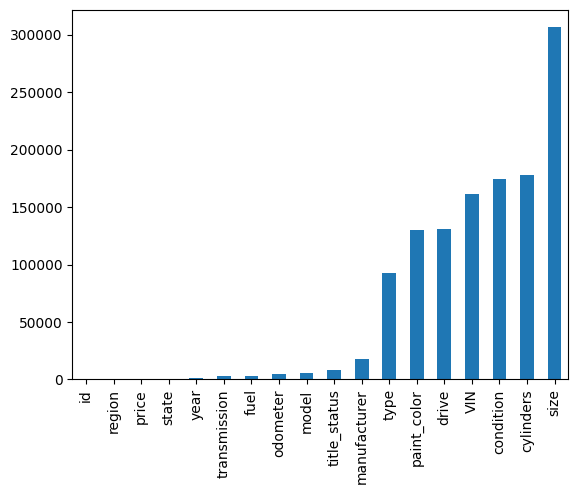

In [10]:
cars_df = pd.read_csv('data/vehicles.csv')
print(cars_df.describe())
print(cars_df.info())
print(cars_df.head())

missing_counts = cars_df.isnull().sum().sort_values()
print(missing_counts)
missing_counts.plot(kind='bar')

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [ ]:
# there are 306361 of size column missing out of 426880 ,
# removing the size column,  region, also droping VIN and id features too
# anylized models and the data has integrity issue where one model car is identified with different names in addition some is not
# clear , while i think Model is important in pricing i fined fixing this feature a very time consumming and will delete it for this 
# excersize. In addition i will drop the region, id and VIN features as they dont seem to be relevant to car price.
cars_df.drop(columns=['size', 'VIN', 'id', 'region', 'model'], inplace = True)
cars_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         426880 non-null  int64  
 1   year          425675 non-null  float64
 2   manufacturer  409234 non-null  str    
 3   condition     252776 non-null  str    
 4   cylinders     249202 non-null  str    
 5   fuel          423867 non-null  str    
 6   odometer      422480 non-null  float64
 7   title_status  418638 non-null  str    
 8   transmission  424324 non-null  str    
 9   drive         296313 non-null  str    
 10  type          334022 non-null  str    
 11  paint_color   296677 non-null  str    
 12  state         426880 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 42.3 MB


In [ ]:
# working on cylinders  Feature
#print(cars_df.value_counts('cylinders', dropna=False))
# replace cylinder to numerical values
cars_df['cylinders'].replace(['other', '3 cylinders', '4 cylinders', '5 cylinders', '6 cylinders', '8 cylinders', '10 cylinders', '12 cylinders'],
                             [0,3,4,5,6,8,10,12],
                             inplace=True)

#Since the most common Cylinders are 4, 6, 8. i will give equally each one third of the NaN
fold_values = ['4.0', '6.0', '8.0'  ]
nan_indices = cars_df[cars_df['cylinders'].isna()].index

# Split NaN indices into 3 folds as evenly as possible
folds = np.array_split(nan_indices, 3)

# Assign different values to each fold
for fold_idx, indices in enumerate(folds):
    cars_df.loc[indices, 'cylinders'] = fold_values[fold_idx]

#print(cars_df.value_counts('cylinders', dropna=False))

#=====================================================================================================

#working with condition 
#print(cars_df.value_counts('condition', dropna=False))

#Since the most common condition are good and excellent i will give equally each one half of the NaN
fold_values = ['good', 'excellent']
nan_indices = cars_df[cars_df['condition'].isna()].index

# Split NaN indices into 3 folds as evenly as possible
folds = np.array_split(nan_indices, 2)

# Assign different values to each fold
for fold_idx, indices in enumerate(folds):
    cars_df.loc[indices, 'condition'] = fold_values[fold_idx]

#cars_df.value_counts('condition', dropna=False)

#=====================================================================================================

#working with drive
#print(cars_df.value_counts('drive', dropna=False))

# will divide NaN equilly between the drive types
fold_values = ['4wd', 'fwd', 'rwd']
nan_indices = cars_df[cars_df['drive'].isna()].index

# Split NaN indices into 3 folds as evenly as possible
folds = np.array_split(nan_indices, 3)

# Assign different values to each fold
for fold_idx, indices in enumerate(folds):
    cars_df.loc[indices, 'drive'] = fold_values[fold_idx]

#cars_df.value_counts('drive', dropna=False)

#=====================================================================================================

#working with paint_color
#print(cars_df.value_counts('paint_color', dropna=False))

# will divide NaN beween the most common colors
fold_values = ['white', 'black', 'silver', 'blue', 'red', 'grey']
nan_indices = cars_df[cars_df['paint_color'].isna()].index

# Split NaN indices into 3 folds as evenly as possible
folds = np.array_split(nan_indices, 6)

# Assign different values to each fold
for fold_idx, indices in enumerate(folds):
    cars_df.loc[indices, 'paint_color'] = fold_values[fold_idx]

#cars_df.value_counts('paint_color', dropna=False)

#=====================================================================================================

# analyzing type feature
#print(cars_df.value_counts('type', dropna=False))

# will divide NaN beween the most common car type
fold_values = ['sedan', 'SUV', 'pickup', 'truck', 'coupe', 'hatchback', 'wagon']
nan_indices = cars_df[cars_df['type'].isna()].index

# Split NaN indices into 3 folds as evenly as possible
folds = np.array_split(nan_indices, 7)

# Assign different values to each fold
for fold_idx, indices in enumerate(folds):
    cars_df.loc[indices, 'type'] = fold_values[fold_idx]

#cars_df.value_counts('type', dropna=False)

#=====================================================================================================

# analyze manufacturer
#print(cars_df.value_counts('manufacturer', dropna=False))

# set the NaN to other manufacturer
cars_df['manufacturer'].fillna('other',inplace=True)
#print(cars_df.value_counts('manufacturer', dropna=False))

# analyze dropping the rest of NaN
cars_df.dropna(inplace=True)
missing_counts = cars_df.isnull().sum().sort_values()
print(missing_counts)
print(cars_df.head())
print(cars_df.info())

price           0
year            0
manufacturer    0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
dtype: int64
    price    year manufacturer  condition    cylinders fuel  odometer  \
27  33590  2014.0          gmc       good  8 cylinders  gas   57923.0   
28  22590  2010.0    chevrolet       good  8 cylinders  gas   71229.0   
29  39590  2020.0    chevrolet       good  8 cylinders  gas   19160.0   
30  30990  2017.0       toyota       good  8 cylinders  gas   41124.0   
31  15000  2013.0         ford  excellent  6 cylinders  gas  128000.0   

   title_status transmission drive    type paint_color state  
27        clean        other   4wd  pickup       white    al  
28        clean        other   4wd  pickup        blue    al  
29        clean        other   4wd  pickup         red    al  
30        clean        other   4wd  pickup         red    al  

In [13]:
# encode non numerical data
features = cars_df[['manufacturer', 'condition', 'fuel', 'cylinders', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']]
target = cars_df['price']

enc = TargetEncoder(target_type='continuous')
enc.set_output(transform='pandas') 
features_enc = enc.fit_transform(features, target)

# putting back the two dataframes together
cars_enc_df = pd.concat([cars_df[['price', 'year', 'odometer']], features_enc], axis=1)
print(cars_enc_df.head())

    price    year  odometer   manufacturer     condition          fuel  \
27  33590  2014.0   57923.0   32957.942020  93733.007574  77558.731958   
28  22590  2010.0   71229.0  120616.997194  79156.947311  89208.222705   
29  39590  2020.0   19160.0  144421.508482  94412.079249  78020.648212   
30  30990  2017.0   41124.0  158046.938484  94412.079249  78020.648212   
31  15000  2013.0  128000.0   41650.595802  67603.000862  89208.222705   

        cylinders  title_status  transmission          drive           type  \
27  173991.678592  83891.212438  28475.365287  121220.796372  168305.085096   
28  173678.127605  89454.654883  28456.758599  143019.270069  168397.825784   
29  101971.342336  84287.103091  28409.668326  121275.946908   81754.325849   
30  101971.342336  84287.103091  28409.668326  121275.946908   81754.325849   
31   72754.378442  89454.654883  94370.904353   36290.860777   26087.852179   

      paint_color          state  
27  105229.117512  295887.661516  
28   99942

<Axes: xlabel='year', ylabel='price'>

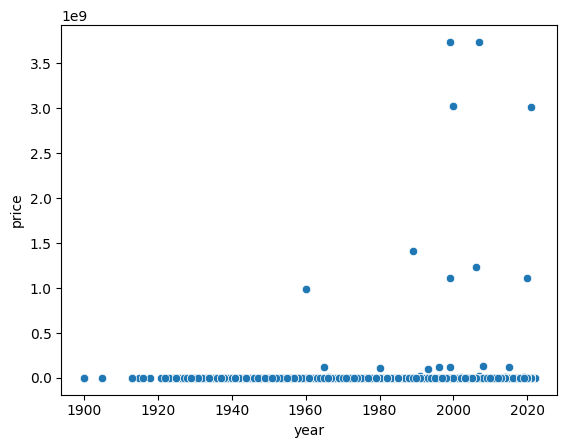

In [ ]:
 # working with price target data 
sns.scatterplot(data=cars_df, x='year', y='price')

# from the plot bellow we see that there are outlier prices that are in billions and million
# i will use the log of the price to normalize it and no more outliers


<Axes: xlabel='year', ylabel='price'>

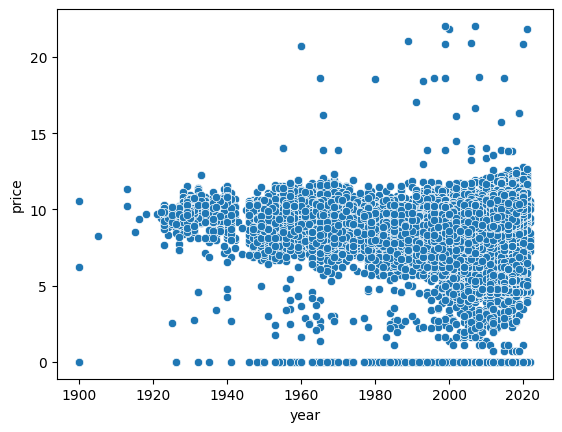

In [15]:
#cars_df = cars_df[cars_df['price'] < 500000]
cars_df['price'] = np.log(cars_df['price'])
sns.scatterplot(data=cars_df, x='year', y='price')

<Axes: xlabel='odometer', ylabel='price'>

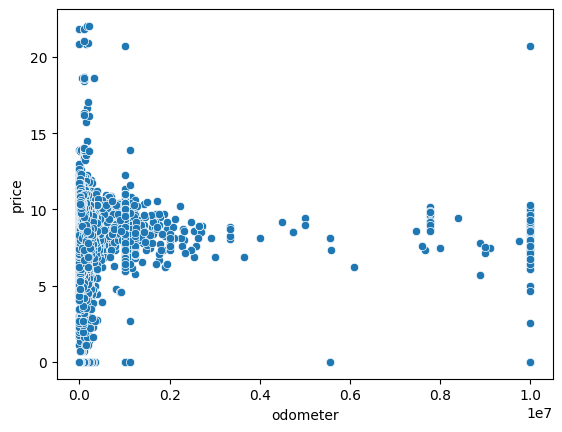

In [16]:
# relation of price to manufacture
sns.scatterplot(data=cars_df, x='odometer', y='price')

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [17]:
auto_X = cars_enc_df.drop(['price'], axis = 1)
auto_y = cars_enc_df['price']
auto_X_train, auto_X_test, auto_y_train, auto_y_test = train_test_split(auto_X, auto_y, 
                                                                       test_size = 0.3,
                                                                       random_state = 42)
print(auto_X_train.shape, auto_X_test.shape, auto_y_train.shape, auto_y_test.shape)
print(auto_X_train.head())
print(auto_y_train.head())

(276325, 12) (118426, 12) (276325,) (118426,)
          year  odometer   manufacturer     condition          fuel  \
365689  2017.0  115300.0  114529.905066  41710.098715  88379.170171   
105831  2010.0  201192.0  137385.496884  93733.007574  79881.953085   
255419  2011.0   96411.0   19530.647175  45404.758104  54827.923981   
409063  2019.0   22344.0  301427.052809  45404.758104  54827.923981   
285537  2006.0   92000.0   21347.636833  42734.082895  99312.058512   

            cylinders  title_status  transmission          drive  \
365689   72409.255519  89208.650550  89579.876624  142631.416582   
105831  158634.839786  83891.212438  78050.093258   66543.111602   
255419   83626.103089  15597.193001  53356.015105   40410.458211   
409063   72756.870918  60409.124819  53356.015105   96057.100371   
285537   95334.521269  60409.124819  53356.015105   21132.180187   

                type    paint_color         state  
365689  96852.576006   20140.233878  20524.049174  
105831  25729.

In [ ]:
# first i would like to find the optimal polynomial feature degree
def simple_cross_validation(X_train, y_train, X_test, y_test):
    best_pipe = None #placeholder for best model
    best_mse = np.inf #set best mse to infinity to begin
    for i in range(1, 5):
        pipe = Pipeline([('pfeat', PolynomialFeatures(degree = i, include_bias=False)),
                    ('linreg', LinearRegression())])
        pipe.fit(X_train, y_train)
        test_preds = pipe.predict(X_test)
        test_mse = mean_squared_error(y_test, test_preds)
        if test_mse < best_mse:
            best_mse = test_mse
            best_pipe = pipe
    return best_pipe


best_model = simple_cross_validation(auto_X_train, auto_y_train, auto_X_test, auto_y_test)
best_model.get_params() 


#NOTE  : i tried to fined the best polynomial degree by using up to 20 degree 
# but i could not go more than 5 because of memory error (see bellow) and the result was best degree is 1 

# MemoryError: Unable to allocate 39.8 GiB for an array with shape (287519, 18563) and data type float64


{'memory': None,
 'steps': [('pfeat', PolynomialFeatures(degree=1, include_bias=False)),
  ('linreg', LinearRegression())],
 'transform_input': None,
 'verbose': False,
 'pfeat': PolynomialFeatures(degree=1, include_bias=False),
 'linreg': LinearRegression(),
 'pfeat__degree': 1,
 'pfeat__include_bias': False,
 'pfeat__interaction_only': False,
 'pfeat__order': 'C',
 'linreg__copy_X': True,
 'linreg__fit_intercept': True,
 'linreg__n_jobs': None,
 'linreg__positive': False,
 'linreg__tol': 1e-06}

In [24]:
# using a sequential Feature selector
sequential_pipe = Pipeline([('polyfeatures', PolynomialFeatures(degree = 1, include_bias = False)),
                            ('scaler', StandardScaler()),
                            ('selector', SequentialFeatureSelector(LinearRegression(), n_features_to_select=6)),
                            ('linreg', LinearRegression())])
sequential_pipe.fit(auto_X_train, auto_y_train)
sequential_train_mse = mean_squared_error(auto_y_train, sequential_pipe.predict(auto_X_train))
sequential_test_mse = mean_squared_error(auto_y_test, sequential_pipe.predict(auto_X_test))

poly_names = sequential_pipe.named_steps['polyfeatures'].get_feature_names_out(input_features=auto_X_train.columns)
selected_mask = sequential_pipe.named_steps['selector'].get_support()
selected_column_names = poly_names[selected_mask]
coef = sequential_pipe.named_steps['linreg'].coef_
#print(coef.shape)
#print(type(coef))
#print(selected_column_names.shape)
#print(type(selected_column_names))
best_features_df = pd.DataFrame(coef.reshape(1, 6),  columns=selected_column_names)
print(best_features_df.sort_values(by=0, axis=1))
print(sequential_train_mse)
print(sequential_test_mse)
sequential_pipe


   title_status         state   cylinders  transmission  manufacturer  \
0 -16584.886352 -16371.837798  8740.44308  10204.210126  11882.745145   

      condition  
0  14977.541527  
186057706265141.62
100558377539466.86


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polyfeatures', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",1
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [25]:
# using GridSearchCV with kfold equal 5
lasso_pipe = Pipeline([('polyfeatures', PolynomialFeatures(degree = 1, include_bias = False)),
                       ('scaler', StandardScaler()),
                       ('lasso', Lasso())
                      ])

#param_grid = {'lasso_alpha': 10**np.linspace(-5, 4, 100)}

param_grid = {
    'lasso__alpha': 10**np.linspace(-5, 4, 100), 
    'lasso__max_iter': [1000, 5000]
}

model_finder = GridSearchCV(estimator = lasso_pipe, 
                            param_grid = param_grid,
                            scoring = 'neg_mean_squared_error',
                            cv = 5)

features = ['year', 'manufacturer', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
model_finder.fit(cars_enc_df[features], cars_enc_df['price'])
print(f"Best Alpha: {model_finder.best_params_['lasso__alpha']}")
best_model = model_finder.best_estimator_
print(best_model)
coef = best_model.named_steps['lasso'].coef_
best_features_df = pd.DataFrame(best_model.named_steps['lasso'].coef_.  reshape(1, len(coef)),
                                columns = best_model.named_steps['polyfeatures'].get_feature_names_out())
best_features_df = best_features_df[best_features_df.columns[(abs(best_features_df) > 0).any()]]
print(best_features_df.sort_values(by=0, axis=1))


Best Alpha: 8111.308307896889
Pipeline(steps=[('polyfeatures',
                 PolynomialFeatures(degree=1, include_bias=False)),
                ('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=np.float64(8111.308307896889)))])
           year          fuel   paint_color          type        state  \
0 -43804.023861 -30850.243117 -19208.254532 -12571.838364 -7331.577452   

   transmission  title_status    condition         drive       odometer  
0  -2317.822403    -97.570254  7525.611279  23344.583248  122667.319441  


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

From using two different modeling i have found two set of features that has the most effect of the price of a car

1. First modeling is to use SequentialFeatureSelector with LinearRegression , the result of the model suggested the following featurs drive the car price the most as bellow

title_status         state     cylinders    transmission     manufacturer       condition
0 -16584.886352 -16371.837798  8740.44308   10204.210126     11882.745145      14977.541527 

And that title_status and condition is the features that have the biggest effect on the price


2. Second modeling i used Lasso with GridSearchCV and k-fold = 5 , the result was different as it identified odometer and year of the car the two features that have the most effect. one thing to note i was expecting the odometer to have a negative value as the odometer goes up the price of the car would go down 

      year          fuel        paint_color      type        state        transmission      title_status    condition         drive       odometer  
0 -43804.023861 -30850.243117 -19208.254532 -12571.838364 -7331.577452   -2317.822403       -97.570254      7525.611279   23344.583248  122667.319441  


Nwverthe less with the result i have i would recomend to take the 4 feaurs from both models as the biggest factors of the price of a car and they are 
year, odometer, title_status and condition

While cleaning the data i removed the model feature from the dataset, the data did not have data integrety and same model of car was identified with different names. i think it is was better for me to fix that feature and include it in the dataset for anylysis, But the time was short to to such work.

I would also like to try different encoding techniques to see what effect has on the feature selection result. 

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.